# Part 4: Preprocessing Temporal Data - Stock Market Dataset

---
## Mô tả Dataset: Stock Market Data

### 1. Nguồn dữ liệu
- **Dataset**: Stock Market Data (NASDAQ, NYSE, S&P500)
- **Link Kaggle**: https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs

### 2. Cấu trúc thư mục
```
data/temporal/stock_market_data/
├── forbes2000/    (2246 files)
├── nasdaq/        (3617 files)
├── nyse/          (2516 files)
└── sp500/         (831 files)
    ├── csv/       (409 file CSV)
    └── json/      (422 file JSON)
```
**Tổng cộng**: ~9210 files cho các cổ phiếu từ 4 sàn giao dịch lớn của Mỹ.

### 3. Cấu trúc file CSV
Mỗi file CSV chứa dữ liệu lịch sử của một mã cổ phiếu với các cột:

| Cột | Kiểu dữ liệu | Mô tả |
|-----|--------------|-------|
| **Date** | String (DD-MM-YYYY) | Ngày giao dịch |
| **Open** | Float | Giá mở cửa |
| **High** | Float | Giá cao nhất trong ngày |
| **Low** | Float | Giá thấp nhất trong ngày |
| **Close** | Float | Giá đóng cửa |
| **Volume** | Integer | Khối lượng giao dịch |
| **Adjusted Close** | Float | Giá đóng cửa đã điều chỉnh (tính cả chia cổ tức, stock split) |

### 4. Lý do chọn mã cổ phiếu Apple (AAPL)

Chúng tôi chọn **Apple Inc. (AAPL)** vì các lý do sau:

1. **Dữ liệu phong phú**: AAPL có lịch sử giao dịch từ năm 1980 đến nay (~44 năm), cung cấp đủ dữ liệu để phân tích xu hướng dài hạn.

2. **Tính thanh khoản cao**: Apple là một trong những cổ phiếu được giao dịch nhiều nhất trên thị trường, đảm bảo dữ liệu liên tục và đáng tin cậy.

3. **Đại diện cho thị trường**: AAPL là thành phần của cả 3 chỉ số chính:
   - S&P 500
   - NASDAQ Composite
   - Dow Jones Industrial Average

4. **Nhiều sự kiện thú vị**: Lịch sử giá AAPL bao gồm nhiều sự kiện quan trọng như:
   - Stock splits (chia tách cổ phiếu)
   - Các đợt tăng/giảm giá mạnh
   - Khủng hoảng tài chính 2008, COVID-19 2020

5. **File size phù hợp**: ~10,590 records (~1.2 MB) - đủ lớn để thể hiện các kỹ thuật preprocessing nhưng không quá nặng để xử lý.

### 5. Đặc điểm dữ liệu chuỗi thời gian
- **Tần suất**: Dữ liệu hàng ngày (daily)
- **Khoảng trống tự nhiên**: Cuối tuần và ngày lễ không có giao dịch
- **Tính chu kỳ**: Có patterns theo ngày trong tuần, tháng, quý
- **Xu hướng**: Có xu hướng tăng dài hạn


## Import Thư viện

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#for autocorrelation
from pandas.plotting import autocorrelation_plot

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## Load Data
Cho phần xử lý này, em sẽ sử dụng dữ liệu cổ phiếu Apple (AAPL) từ S&P 500.

In [102]:
df = pd.read_csv('../data/temporal/stock_market_data/sp500/csv/AAPL.csv')

Thông tin tổng quan dữ liệu

In [103]:
print(f"Số dòng: {len(df)}")
print(f"Số cột: {len(df.columns)}")
print(f"\nCác cột: {df.columns.tolist()}")
df.head(10)

Số dòng: 10590
Số cột: 7

Các cột: ['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492
5,19-12-1980,0.126116,0.126116,48630400,0.126674,0.126116,0.098137
6,22-12-1980,0.132254,0.132254,37363200,0.132813,0.132254,0.102913
7,23-12-1980,0.137835,0.137835,46950400,0.138393,0.137835,0.107256
8,24-12-1980,0.145089,0.145089,48003200,0.145647,0.145089,0.112901
9,26-12-1980,0.158482,0.158482,55574400,0.159040,0.158482,0.123322


Thông tin các thuộc tính

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


---
## a) Parsing Date and Time

#### **Yêu cầu bài làm**
-  Parse datetime strings into proper datetime objects. 
- Handle different datetime formats and extract components (year, month, day, hour, etc.).
- Set a proper datetime index for the time series.

**Đầu tiên, chúng ta sẽ tiến hành kiểm tra dữ liệu và kiểu dữ liệu hiện tại của biến thời gian.**

In [105]:
print("Kiểu dữ liệu cột Date:", df['Date'].dtype)
print("\nMẫu dữ liệu Date:")
print(df['Date'].head(10))

Kiểu dữ liệu cột Date: object

Mẫu dữ liệu Date:
0    12-12-1980
1    15-12-1980
2    16-12-1980
3    17-12-1980
4    18-12-1980
5    19-12-1980
6    22-12-1980
7    23-12-1980
8    24-12-1980
9    26-12-1980
Name: Date, dtype: object


Dữ liệu đang ở kiểu *object* với cấu trúc DD-MM-YYYY.  
**Bây giờ ta sẽ tiến hành parse dữ liệu này thành datetime object.**

In [106]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print("Kiểu dữ liệu sau khi parse:", df['Date'].dtype)
print("\nMẫu dữ liệu:")
df.head()

Kiểu dữ liệu sau khi parse: datetime64[ns]

Mẫu dữ liệu:


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


**Để tái sử dụng cho các phần sau của bài làm, em sẽ extract thành phần của datetime và tách thành các cột riêng**

In [107]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayName'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("Các thành phần thời gian đã trích xuất:")
df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayName', 'Quarter', 'WeekOfYear']].head(10)

Các thành phần thời gian đã trích xuất:


,Date,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
0,1980-12-12,1980,12,12,4,Friday,4,50
1,1980-12-15,1980,12,15,0,Monday,4,51
2,1980-12-16,1980,12,16,1,Tuesday,4,51
3,1980-12-17,1980,12,17,2,Wednesday,4,51
4,1980-12-18,1980,12,18,3,Thursday,4,51
5,1980-12-19,1980,12,19,4,Friday,4,51
6,1980-12-22,1980,12,22,0,Monday,4,52
7,1980-12-23,1980,12,23,1,Tuesday,4,52
8,1980-12-24,1980,12,24,2,Wednesday,4,52
9,1980-12-26,1980,12,26,4,Friday,4,52


Xử lý xong kiểu dữ liệu rồi ta sẽ dựng trục thời gian cho dữ liệu (dùng pandas datetime index cho Date).  
**Đặt cột Date làm index để xử lý dữ liệu chuỗi thời gian.**

In [108]:
df_caua = df.set_index('Date')

**Sắp xếp lại theo thời gian (phòng trường hợp dữ liệu chưa được sắp xếp)**

In [109]:
df_caua = df_caua.sort_index()

**Kiểm tra phạm vi thời gian của dữ liệu**

In [110]:
start_date = df_caua.index.min()
end_date = df_caua.index.max()

print("Phạm vi thời gian của dữ liệu:")
print("Từ:", start_date)
print("Đến:", end_date)

Phạm vi thời gian của dữ liệu:
Từ: 1980-12-12 00:00:00
Đến: 2022-12-12 00:00:00


**Tính tổng số ngày trong khoảng thời gian này**

In [111]:
total_days = (end_date - start_date).days
print("Tổng thời gian:", total_days, "ngày")

df_caua.head()

Tổng thời gian: 15340 ngày


,Low,Open,Volume,High,Close,Adjusted Close,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
Date,,,,,,,,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874,1980,12,12,4,Friday,4,50
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663,1980,12,15,0,Monday,4,51
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715,1980,12,16,1,Tuesday,4,51
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886,1980,12,17,2,Wednesday,4,51
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492,1980,12,18,3,Thursday,4,51


**Để có thể quan sát xu hướng dữ liệu time series sau khi format về Datetime object, em sẽ dùng line chart cho giá chốt (Close price) để visualize.**

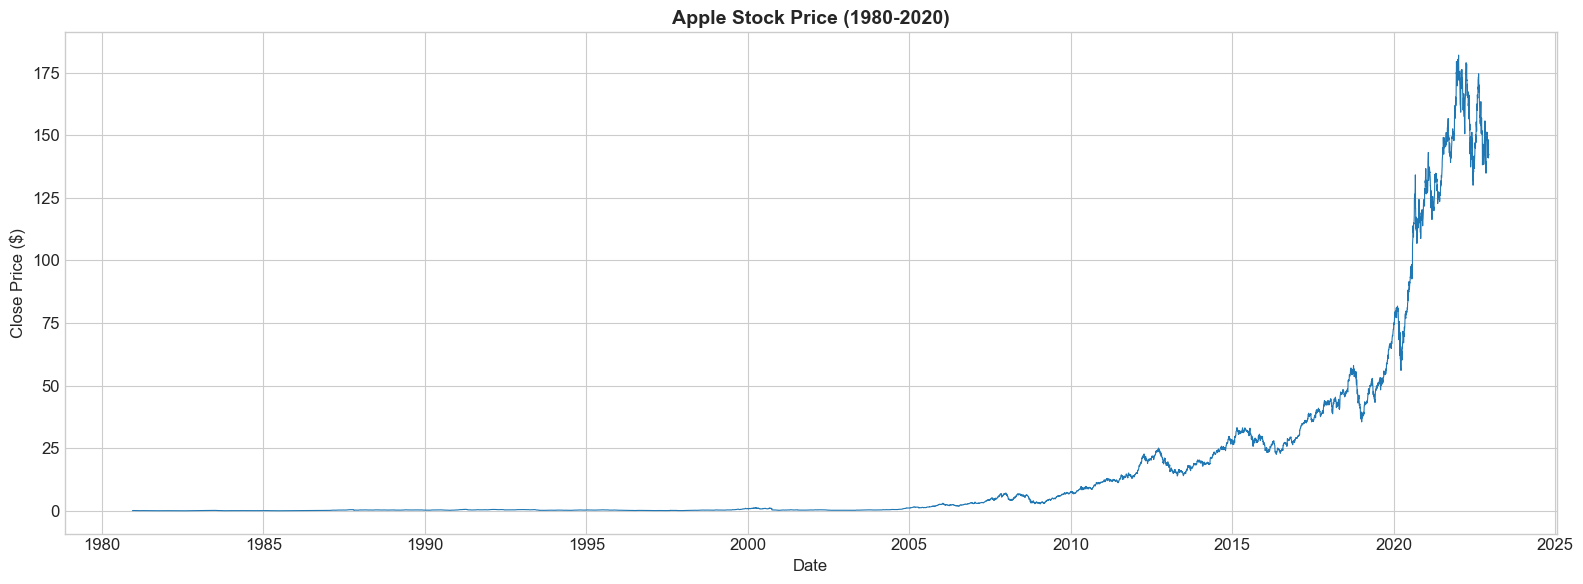

In [112]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_caua.index, df_caua['Close'], linewidth=0.8)
ax.set_title('Apple Stock Price (1980-2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

---
## b) Handling Time Gaps

#### **Yêu cầu bài làm**
-  Identify missing timestamps.
- Apply forward fill or backward fill methods.
- Use interpolation techniques (linear, polynomial, spline) and compare their effectiveness.

**Reset lại index trước khi fill**  
Em sẽ tạo 1 df mới dựa trên `df_caua` để tính toán time gaps.  

In [113]:
df_gap = df_caua.reset_index()  # Dùng lại kết quả phần a)

**Tính khoảng cách thời gian giữa các ngày liên tiếp**

In [114]:
df_gap['TimeDiff'] = df_gap['Date'].diff()

df_gap.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear,TimeDiff
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874,1980,12,12,4,Friday,4,50,NaT
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663,1980,12,15,0,Monday,4,51,3 days
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715,1980,12,16,1,Tuesday,4,51,1 days
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886,1980,12,17,2,Wednesday,4,51,1 days
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492,1980,12,18,3,Thursday,4,51,1 days


Do dữ liệu là ở cấp ngày (mỗi datapoint cách nhau 1 ngày), nên để tìm time gaps em sẽ tìm những datapoint cách nhau nhiều hơn 1 ngày

In [115]:
gaps = df_gap[df_gap['TimeDiff'] > pd.Timedelta(days=1)]
print(f"Số khoảng trống > 1 ngày: {len(gaps)}")
print(f"\nPhân bố khoảng trống:")
print(gaps['TimeDiff'].value_counts().head(10))

Số khoảng trống > 1 ngày: 2289

Phân bố khoảng trống:
TimeDiff
3 days    1927
4 days     262
2 days      97
5 days       2
7 days       1
Name: count, dtype: int64


Mình đã có số liệu về những time gaps đang có của mã cổ phiếu. Bây giờ em sẽ visualize nó lên để có cái nhìn trực quan hơn

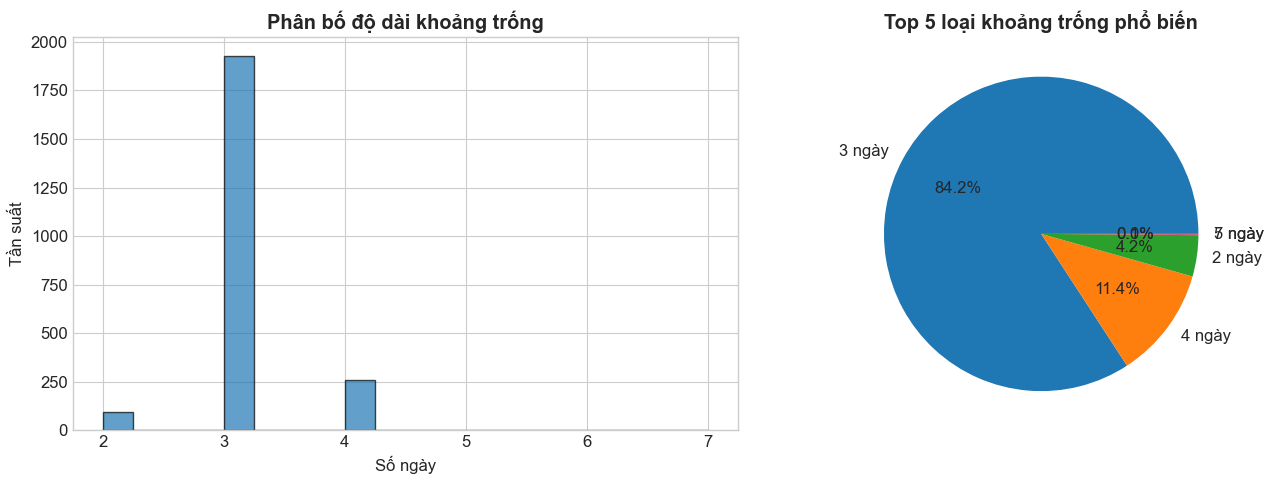

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
gap_days = gaps['TimeDiff'].dt.days
axes[0].hist(gap_days, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân bố độ dài khoảng trống', fontweight='bold')
axes[0].set_xlabel('Số ngày')
axes[0].set_ylabel('Tần suất')

# Pie chart
gap_counts = gap_days.value_counts().head(5)
axes[1].pie(gap_counts.values, labels=[f'{d} ngày' for d in gap_counts.index], autopct='%1.1f%%')
axes[1].set_title('Top 5 loại khoảng trống phổ biến', fontweight='bold')

plt.tight_layout()
plt.show()

Bây giờ em sẽ tạo chuỗi thời gian thực và đối chiếu với dữ liệu xem chúng ta bị thiếu bao nhiêu ngày

Tạo dải ngày liên tục từ ngày đầu đến ngày cuối của dữ liệu

In [117]:
start_date = df_caua.index.min()
end_date = df_caua.index.max()

date_range = pd.date_range(start=start_date, end=end_date, freq='D')

Reindex lại DataFrame để bổ sung các ngày còn thiếu

In [118]:
df_caub = df_caua.reindex(date_range)

So sánh số lượng dòng trước và sau khi reindex

In [119]:
print("Số dòng ban đầu:", len(df_caua))
print("Số dòng sau khi reindex:", len(df_caub))

Số dòng ban đầu: 10590
Số dòng sau khi reindex: 15341


Đếm số ngày bị thiếu dữ liệu (giá trị Close bị NaN)

In [120]:
missing_days = df_caub['Close'].isna().sum()
print("Số ngày thiếu dữ liệu:", missing_days)

Số ngày thiếu dữ liệu: 4751


#### **Các kỹ thuật Handling Time Gaps sử dụng**

Dựa trên yêu cầu bài toán, có **5 kỹ thuật** cần được triển khai và so sánh, bao gồm:

##### **1. Fill Methods**
* **Forward Fill**
* **Backward Fill**

##### **2. Interpolation Methods**
* **Linear Interpolation**
* **Polynomial Interpolation**
* **Spline Interpolation**

Để so sánh và chọn ra kĩ thuật phù hợp, em sẽ áp dụng cho cột `Close` của Dữ liệu. Trong thực tế khi preprocessing toàn bộ dataset để sử dụng, nên fill tất cả các cột giá (Open, High, Low, Close) bằng cùng phương pháp, và xử lý Volume riêng (forward fill hoặc fill = 0).

In [121]:
# 1. Forward Fill
df_ffill = df_caub['Close'].ffill()

# 2. Backward Fill
df_bfill = df_caub['Close'].bfill()

# 3. Linear Interpolation
df_linear = df_caub['Close'].interpolate(method='linear')

# 4. Polynomial Interpolation (order=2)
df_poly = df_caub['Close'].interpolate(method='polynomial', order=2)

# 5. Spline Interpolation (order=3 - cubic spline)
df_spline = df_caub['Close'].interpolate(method='spline', order=3)

**Bây giờ em sẽ lấy 1 khoảng có gap để visualize lên so sánh 5 phương pháp handling time gaps này**

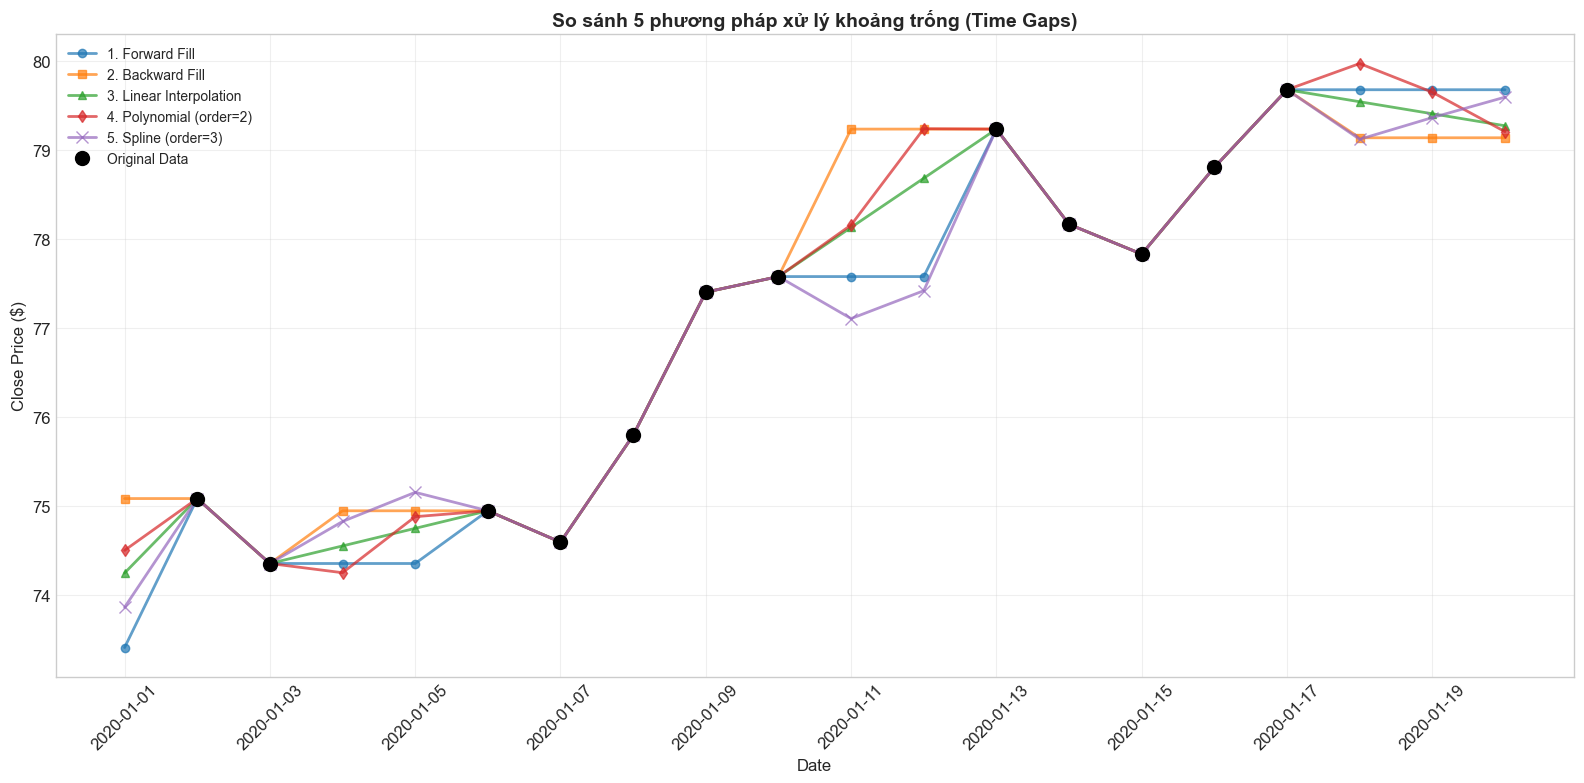

In [122]:
sample_start = '2020-01-01'
sample_end = '2020-01-20'

fig, ax = plt.subplots(figsize=(16, 8))

# Plot all 5 methods
ax.plot(df_ffill[sample_start:sample_end], 'o-', label='1. Forward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_bfill[sample_start:sample_end], 's-', label='2. Backward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_linear[sample_start:sample_end], '^-', label='3. Linear Interpolation', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_poly[sample_start:sample_end], 'd-', label='4. Polynomial (order=2)', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_spline[sample_start:sample_end], 'x-', label='5. Spline (order=3)', alpha=0.7, markersize=8, linewidth=2)

# Plot original data points
original = df_caub['Close'][sample_start:sample_end]
ax.plot(original.dropna(), 'ko', label='Original Data', markersize=10, zorder=5)

ax.set_title('So sánh 5 phương pháp xử lý khoảng trống (Time Gaps)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ chi tiết cho từng phương pháp

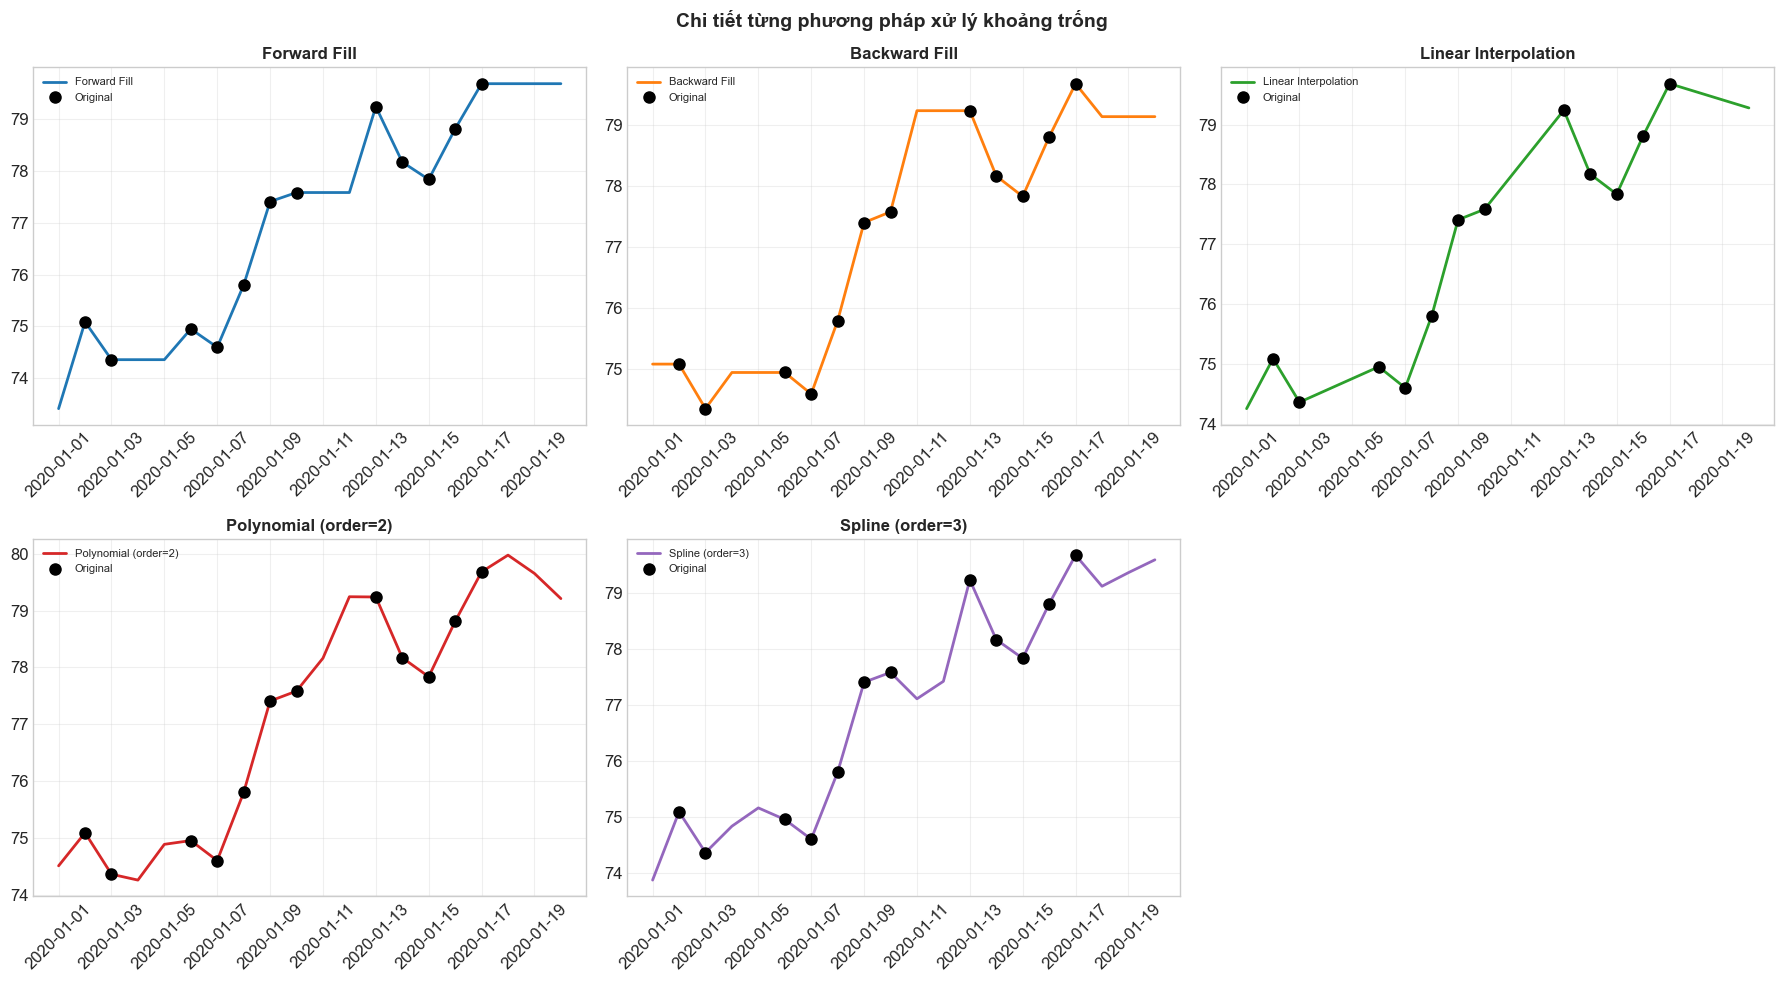

In [123]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sample_start = '2020-01-01'
sample_end = '2020-01-20'

original = df_caub['Close'][sample_start:sample_end]

methods = [
    ('Forward Fill', df_ffill[sample_start:sample_end], 'tab:blue'),
    ('Backward Fill', df_bfill[sample_start:sample_end], 'tab:orange'),
    ('Linear Interpolation', df_linear[sample_start:sample_end], 'tab:green'),
    ('Polynomial (order=2)', df_poly[sample_start:sample_end], 'tab:red'),
    ('Spline (order=3)', df_spline[sample_start:sample_end], 'tab:purple'),
]

for idx, (name, data, color) in enumerate(methods):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    ax.plot(data.index, data.values, '-', color=color, linewidth=2, label=name)
    ax.plot(original.dropna().index, original.dropna().values, 'ko', markersize=8, label='Original')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide last empty subplot
axes[1, 2].axis('off')

plt.suptitle('Chi tiết từng phương pháp xử lý khoảng trống', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Ngoài phụ thuộc vào phương pháp, kết quả handling time gaps còn phụ thuộc vào định lượng sử dụng để interpolate. Đây là bảng so sánh chi tiết

In [124]:
# Phân tích định lượng các phương pháp
# Tính toán các chỉ số so sánh

# Lấy index các điểm có dữ liệu thực
original_data = df_caub['Close'].dropna()

# Tạo bảng so sánh
comparison_data = {
    'Method': ['Forward Fill', 'Backward Fill', 'Linear', 'Polynomial', 'Spline'],
    'Mean': [
        df_ffill.mean(),
        df_bfill.mean(),
        df_linear.mean(),
        df_poly.mean(),
        df_spline.mean()
    ],
    'Std': [
        df_ffill.std(),
        df_bfill.std(),
        df_linear.std(),
        df_poly.std(),
        df_spline.std()
    ],
    'Min': [
        df_ffill.min(),
        df_bfill.min(),
        df_linear.min(),
        df_poly.min(),
        df_spline.min()
    ],
    'Max': [
        df_ffill.max(),
        df_bfill.max(),
        df_linear.max(),
        df_poly.max(),
        df_spline.max()
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print('Bảng so sánh các phương pháp xử lý khoảng trống:')
df_comparison

Bảng so sánh các phương pháp xử lý khoảng trống:


,Method,Mean,Std,Min,Max
0,Forward Fill,16.334488,34.908478,0.049107,182.009995
1,Backward Fill,16.345146,34.924378,0.049107,182.009995
2,Linear,16.339817,34.915811,0.049107,182.009995
3,Polynomial,16.336362,34.911129,0.049107,182.009995
4,Spline,16.344886,34.923188,0.016096,182.009995


**Nhận xét và so sánh 5 phương pháp:**  

| Phương pháp | Đặc điểm | Ưu điểm | Nhược điểm |
|------------|----------|---------|------------|
| **Forward Fill** | Lấy giá trị trước đó | Đơn giản, phù hợp stock data | Không phản ánh xu hướng |
| **Backward Fill** | Lấy giá trị sau đó | Đơn giản | Dùng thông tin tương lai (data leakage) |
| **Linear** | Nội suy tuyến tính | Smooth, phản ánh xu hướng | Giả định thay đổi tuyến tính |
| **Polynomial** | Nội suy đa thức bậc 2 | Capture được đường cong | Có thể overshoot ở biên |
| **Spline** | Nội suy spline bậc 3 | Rất smooth | Phức tạp, có thể overshoot |
 
 
 **Khuyến nghị cho Stock Data:**  
 - **Forward Fill** là lựa chọn phổ biến nhất vì giá cuối cùng được duy trì cho đến khi có giao dịch mới 
 - **Linear Interpolation** phù hợp khi muốn tạo dữ liệu liên tục cho visualization
 - **Backward Fill** sử dụng thông tin ở tương lai để điền vào quá khứ, nên trong các bài toán dự đoán thực tế có thể gây sai lệch kết quả (data leakage). Vì vậy nhóm không khuyến nghị sử dụng phương pháp này.

#### **Áp dụng phương pháp được chọn cho toàn bộ dữ liệu**

Dựa trên phân tích và so sánh ở trên, **Forward Fill** là phương pháp phù hợp nhất cho stock data. Bây giờ em sẽ áp dụng phương pháp này để xử lý toàn bộ các cột trong dataset.

In [125]:
# Tạo bản sao để xử lý
df_filled = df_caub.copy()

# Áp dụng Forward Fill cho tất cả các cột giá
price_columns = ['Open', 'High', 'Low', 'Close', 'OpenInt']
for col in price_columns:
    if col in df_filled.columns:
        df_filled[col] = df_filled[col].ffill()

# Xử lý Volume: forward fill (hoặc có thể fill = 0)
if 'Volume' in df_filled.columns:
    df_filled['Volume'] = df_filled['Volume'].ffill()
    # Nếu muốn fill = 0 thay vì forward fill, dùng: df_filled['Volume'].fillna(0)

# Kiểm tra kết quả
print("Số lượng giá trị NaN còn lại sau khi fill:")
print(df_filled.isna().sum())
print(f"\nTổng số dòng: {len(df_filled)}")
print(f"Dòng hoàn chỉnh (không có NaN): {df_filled.notna().all(axis=1).sum()}")
df_filled.head(10)

Số lượng giá trị NaN còn lại sau khi fill:
Low                  0
Open                 0
Volume               0
High                 0
Close                0
Adjusted Close    4751
Year              4751
Month             4751
Day               4751
DayOfWeek         4751
DayName           4751
Quarter           4751
WeekOfYear        4751
dtype: int64

Tổng số dòng: 15341
Dòng hoàn chỉnh (không có NaN): 10590


,Low,Open,Volume,High,Close,Adjusted Close,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
1980-12-12,0.128348,0.128348,469033600.0,0.128906,0.128348,0.099874,1980.0,12.0,12.0,4.0,Friday,4.0,50
1980-12-13,0.128348,0.128348,469033600.0,0.128906,0.128348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1980-12-14,0.128348,0.128348,469033600.0,0.128906,0.128348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1980-12-15,0.121652,0.122210,175884800.0,0.122210,0.121652,0.094663,1980.0,12.0,15.0,0.0,Monday,4.0,51
1980-12-16,0.112723,0.113281,105728000.0,0.113281,0.112723,0.087715,1980.0,12.0,16.0,1.0,Tuesday,4.0,51
1980-12-17,0.115513,0.115513,86441600.0,0.116071,0.115513,0.089886,1980.0,12.0,17.0,2.0,Wednesday,4.0,51
1980-12-18,0.118862,0.118862,73449600.0,0.119420,0.118862,0.092492,1980.0,12.0,18.0,3.0,Thursday,4.0,51
1980-12-19,0.126116,0.126116,48630400.0,0.126674,0.126116,0.098137,1980.0,12.0,19.0,4.0,Friday,4.0,51
1980-12-20,0.126116,0.126116,48630400.0,0.126674,0.126116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1980-12-21,0.126116,0.126116,48630400.0,0.126674,0.126116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>


**Kết luận phần Handling Time Gaps:**

✅ **Phương pháp được chọn**: Forward Fill (ffill)

**Lý do:**
- Phù hợp với bản chất của stock data (giá không thay đổi khi không có giao dịch)
- Không gây data leakage (không dùng thông tin tương lai)
- Đơn giản, dễ hiểu và giải thích
- Phù hợp cho cả modeling lẫn analysis

**Kết quả:**
- DataFrame `df_filled` đã được xử lý toàn bộ time gaps
- Sẵn sàng cho các bước preprocessing tiếp theo

**Lưu ý:** DataFrame `df_caub` giữ nguyên để có thể quay lại so sánh nếu cần.

---
## c) Extracting Time-Based Features

#### **Yêu cầu bài làm**
- Extract cyclical features (day of week, month, season). 
- Create indicator variables for special periods (holidays, weekends).
- Encode cyclical features using sine/cosine transformations.
- Extract time elapsed since specific events.

**Load df để sẵn sàng cho bước extracting**

In [126]:
df_cauc = df_caub.copy()

Do dữ liệu có tính chu kì -> sin/cos

In [127]:
df_cauc['Month_sin'] = np.sin(2 * np.pi * df_cauc['Month'] / 12)
df_cauc['Month_cos'] = np.cos(2 * np.pi * df_cauc['Month'] / 12)
df_cauc['DayOfWeek_sin'] = np.sin(2 * np.pi * df_cauc['DayOfWeek'] / 7)
df_cauc['DayOfWeek_cos'] = np.cos(2 * np.pi * df_cauc['DayOfWeek'] / 7)
df_cauc['DayOfYear'] = df_cauc.index.dayofyear
df_cauc['DayOfYear_sin'] = np.sin(2 * np.pi * df_cauc['DayOfYear'] / 365)
df_cauc['DayOfYear_cos'] = np.cos(2 * np.pi * df_cauc['DayOfYear'] / 365)

print("Cyclical features:")
df_cauc[['Month', 'Month_sin', 'Month_cos', 'DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos']].head(10)

Cyclical features:


,Month,Month_sin,Month_cos,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
1980-12-12,12.0,-2.449294e-16,1.0,4.0,-0.433884,-0.900969
1980-12-13,NaN,NaN,NaN,NaN,NaN,NaN
1980-12-14,NaN,NaN,NaN,NaN,NaN,NaN
1980-12-15,12.0,-2.449294e-16,1.0,0.0,0.000000,1.000000
1980-12-16,12.0,-2.449294e-16,1.0,1.0,0.781831,0.623490
1980-12-17,12.0,-2.449294e-16,1.0,2.0,0.974928,-0.222521
1980-12-18,12.0,-2.449294e-16,1.0,3.0,0.433884,-0.900969
1980-12-19,12.0,-2.449294e-16,1.0,4.0,-0.433884,-0.900969
1980-12-20,NaN,NaN,NaN,NaN,NaN,NaN
1980-12-21,NaN,NaN,NaN,NaN,NaN,NaN


thêm binary encoding features
- thêm để làm gì?
- động lực

Tạo các biến chỉ báo cho ngày trong tuần

In [128]:
df_cauc['IsMonday'] = (df_cauc['DayOfWeek'] == 0)
df_cauc['IsFriday'] = (df_cauc['DayOfWeek'] == 4)

df_cauc['IsMonday'] = df_cauc['IsMonday'].astype(int)
df_cauc['IsFriday'] = df_cauc['IsFriday'].astype(int)

Các biến liên quan đến thời điểm trong tháng / năm

In [129]:
df_cauc['IsMonthStart'] = df_cauc.index.is_month_start.astype(int)
df_cauc['IsMonthEnd'] = df_cauc.index.is_month_end.astype(int)
df_cauc['IsQuarterEnd'] = df_cauc.index.is_quarter_end.astype(int)
df_cauc['IsYearEnd'] = df_cauc.index.is_year_end.astype(int)

Hàm xác định mùa dựa vào tháng

In [130]:
def get_season(month):
    if month == 12 or month == 1 or month == 2:
        return 'Winter'
    elif month == 3 or month == 4 or month == 5:
        return 'Spring'
    elif month == 6 or month == 7 or month == 8:
        return 'Summer'
    else:
        return 'Fall'

Tạo cột Season

In [131]:
df_cauc['Season'] = df_cauc['Month'].apply(get_season)

print("Một số biến chỉ báo sau khi tạo:")
df_cauc[['IsMonday', 'IsFriday', 'IsMonthEnd',
         'IsQuarterEnd', 'Season']].head(10)


Một số biến chỉ báo sau khi tạo:


,IsMonday,IsFriday,IsMonthEnd,IsQuarterEnd,Season
1980-12-12,0,1,0,0,Winter
1980-12-13,0,0,0,0,Fall
1980-12-14,0,0,0,0,Fall
1980-12-15,1,0,0,0,Winter
1980-12-16,0,0,0,0,Winter
1980-12-17,0,0,0,0,Winter
1980-12-18,0,0,0,0,Winter
1980-12-19,0,1,0,0,Winter
1980-12-20,0,0,0,0,Fall
1980-12-21,0,0,0,0,Fall


visualize dữ liệu theo chu kì (chu kì thiết lập bằng date ở trên)

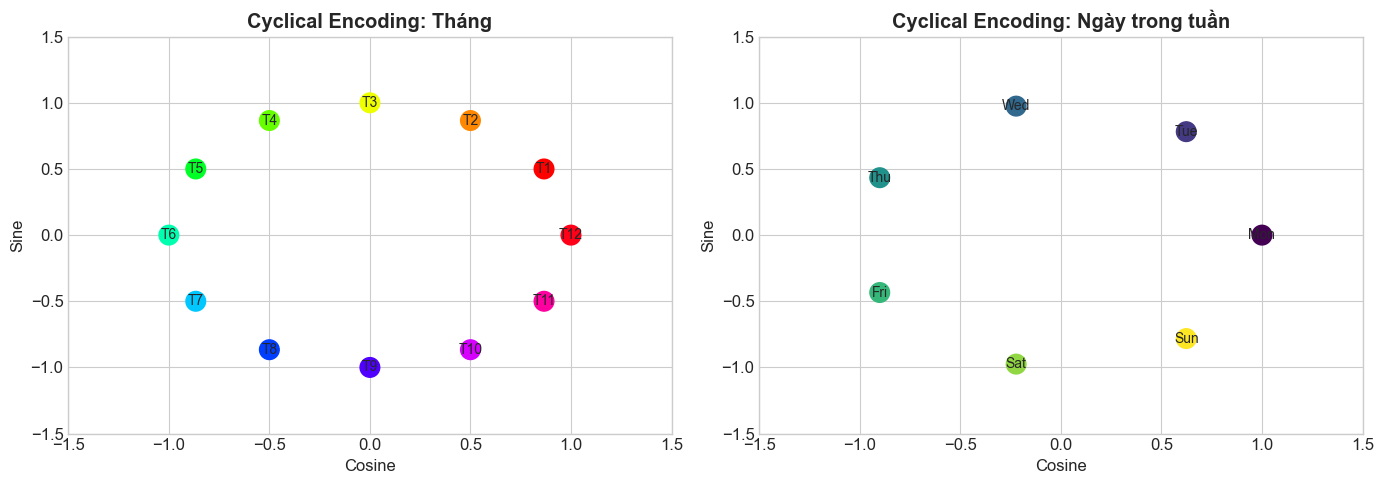

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)
axes[0].scatter(month_cos, month_sin, c=months, cmap='hsv', s=200)
for i, m in enumerate(months):
    axes[0].annotate(f'T{m}', (month_cos[i], month_sin[i]), fontsize=10, ha='center', va='center')
axes[0].set_xlabel('Cosine')
axes[0].set_ylabel('Sine')
axes[0].set_title('Cyclical Encoding: Tháng', fontweight='bold')
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)

days = np.arange(0, 7)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_sin = np.sin(2 * np.pi * days / 7)
day_cos = np.cos(2 * np.pi * days / 7)
axes[1].scatter(day_cos, day_sin, c=days, cmap='viridis', s=200)
for i, d in enumerate(day_names):
    axes[1].annotate(d, (day_cos[i], day_sin[i]), fontsize=10, ha='center', va='center')
axes[1].set_xlabel('Cosine')
axes[1].set_ylabel('Sine')
axes[1].set_title('Cyclical Encoding: Ngày trong tuần', fontweight='bold')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

Xem thêm 1 số visualize của các thuộc tính khác dựa trên feature vừa extract

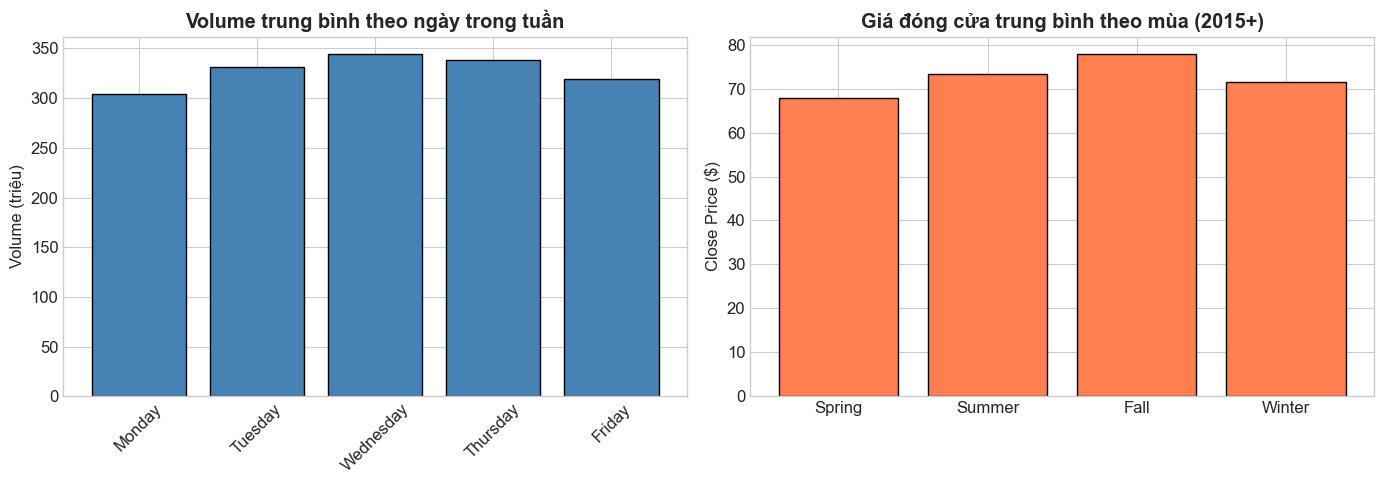

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#vol
vol_by_day = df_cauc.groupby('DayName')['Volume'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
axes[0].bar(vol_by_day.index, vol_by_day.values / 1e6, color='steelblue', edgecolor='black')
axes[0].set_title('Volume trung bình theo ngày trong tuần', fontweight='bold')
axes[0].set_ylabel('Volume (triệu)')
axes[0].tick_params(axis='x', rotation=45)

#close
recent_data = df_cauc[df_cauc['Year'] >= 2015]
close_by_season = recent_data.groupby('Season')['Close'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
axes[1].bar(close_by_season.index, close_by_season.values, color='coral', edgecolor='black')
axes[1].set_title('Giá đóng cửa trung bình theo mùa (2015+)', fontweight='bold')
axes[1].set_ylabel('Close Price ($)')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Cyclical encoding giúp model hiểu được tính chu kỳ (tháng 12 gần với tháng 1)
- Volume giao dịch có xu hướng khác nhau theo ngày trong tuần
- Các indicator variables giúp capture hiệu ứng đầu/cuối tháng, cuối quý

---
## d) Resampling Time Series Data

#### **Yêu cầu đề bài**
-  Choose suitable techniques such as upsampling (interpolation), downsampling (aggregation), or different aggregation functions (mean, sum, max, min). 
- Then, compare the effects of different resampling frequencies on data characteristics.

#### **Phương hướng tiếp cận**
- Em sẽ thử nghiệm cả upsampling và downsampling trên bộ dữ liệu này để so sánh và đối chiếu các phương pháp. Từ đó tìm ra lựa chọn phù hợp cho bộ dữ liệu cũng như cho những loại dữ liệu Temporal có cùng tính chất.

#### Down-sampling

**Gộp dữ liệu theo tuần**

In [134]:
df_weekly = df_cauc.resample('W')

**Lấy giá mở cửa đầu tuần**

In [135]:
weekly_open = df_weekly['Open'].first()

**Giá cao nhất và thấp nhất trong tuần**

In [136]:
weekly_high = df_weekly['High'].max()
weekly_low = df_weekly['Low'].min()

**Giá đóng cửa cuối tuần**

In [137]:
weekly_close = df_weekly['Close'].last()

**Tổng khối lượng giao dịch trong tuần**

In [138]:
weekly_volume = df_weekly['Volume'].sum()

**Gộp các kết quả lại thành DataFrame**

In [139]:
df_weekly = pd.concat(
    [weekly_open, weekly_high, weekly_low, weekly_close, weekly_volume],
    axis=1
)

print("Kích thước dữ liệu theo tuần:", df_weekly.shape)
df_weekly.head()

Kích thước dữ liệu theo tuần: (2193, 5)


,Open,High,Low,Close,Volume
1980-12-14,0.128348,0.128906,0.128348,0.128348,469033600.0
1980-12-21,0.122210,0.126674,0.112723,0.126116,490134400.0
1980-12-28,0.132254,0.159040,0.132254,0.158482,187891200.0
1981-01-04,0.160714,0.161272,0.152344,0.154018,219452800.0
1981-01-11,0.151228,0.151228,0.135045,0.142299,197904000.0


**So sánh các tần suất resampling**

###### Lấy dữ liệu giá đóng cửa trong giai đoạn 2019–2020

In [140]:
recent = df_cauc['Close']['2019':'2020']
weekly = recent.resample('W').mean()
monthly = recent.resample('ME').mean()

**Visualize**

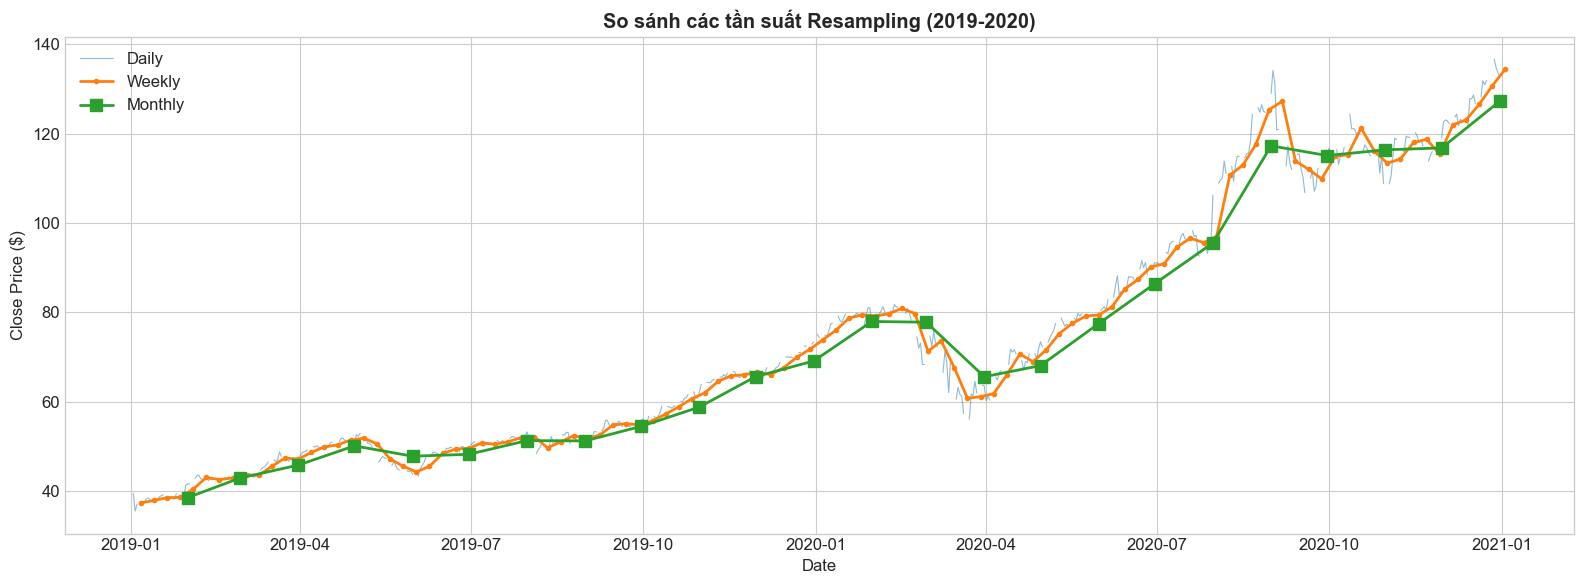

In [141]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent.index, recent.values, alpha=0.5, label='Daily', linewidth=0.8)
ax.plot(weekly.index, weekly.values, 'o-', label='Weekly', linewidth=2, markersize=3)
ax.plot(monthly.index, monthly.values, 's-', label='Monthly', linewidth=2, markersize=8)

ax.set_title('So sánh các tần suất Resampling (2019-2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**So sánh các aggregation functions**

###### Lấy dữ liệu giá đóng cửa trong năm 2020

In [142]:
close_2020 = df_cauc.loc['2020', 'Close']
monthly_close = close_2020.resample('M')

df_agg = pd.DataFrame()
df_agg['mean'] = monthly_close.mean()
df_agg['min'] = monthly_close.min()
df_agg['max'] = monthly_close.max()
df_agg['sum'] = monthly_close.sum()
df_agg['median'] = monthly_close.median()
df_agg['std'] = monthly_close.std()

print("Bảng so sánh các Aggregation Functions (Monthly resampling - 2020):")
df_agg

Bảng so sánh các Aggregation Functions (Monthly resampling - 2020):


,mean,min,max,sum,median,std
2020-01-31,77.979048,74.357498,81.084999,1637.560005,78.169998,2.043097
2020-02-29,77.817631,68.339996,81.800003,1478.534981,79.902496,4.352167
2020-03-31,65.611023,56.092499,75.684998,1443.442505,63.637499,5.709724
2020-04-30,68.096547,60.227501,73.449997,1430.027489,69.025002,3.841231
2020-05-31,77.496376,72.267502,79.807503,1549.927513,78.068752,2.242860
2020-06-30,86.451590,80.462502,91.632500,1901.934982,87.663750,3.695688
2020-07-31,95.566250,91.027496,106.260002,2102.457497,95.615002,3.160567
2020-08-31,117.299762,108.937500,129.039993,2463.294998,115.010002,6.617420
2020-09-30,115.125237,106.839996,134.179993,2417.629967,113.489998,6.986781
2020-10-31,116.413182,108.860001,124.400002,2561.090012,116.240002,3.460588


**Visualize**

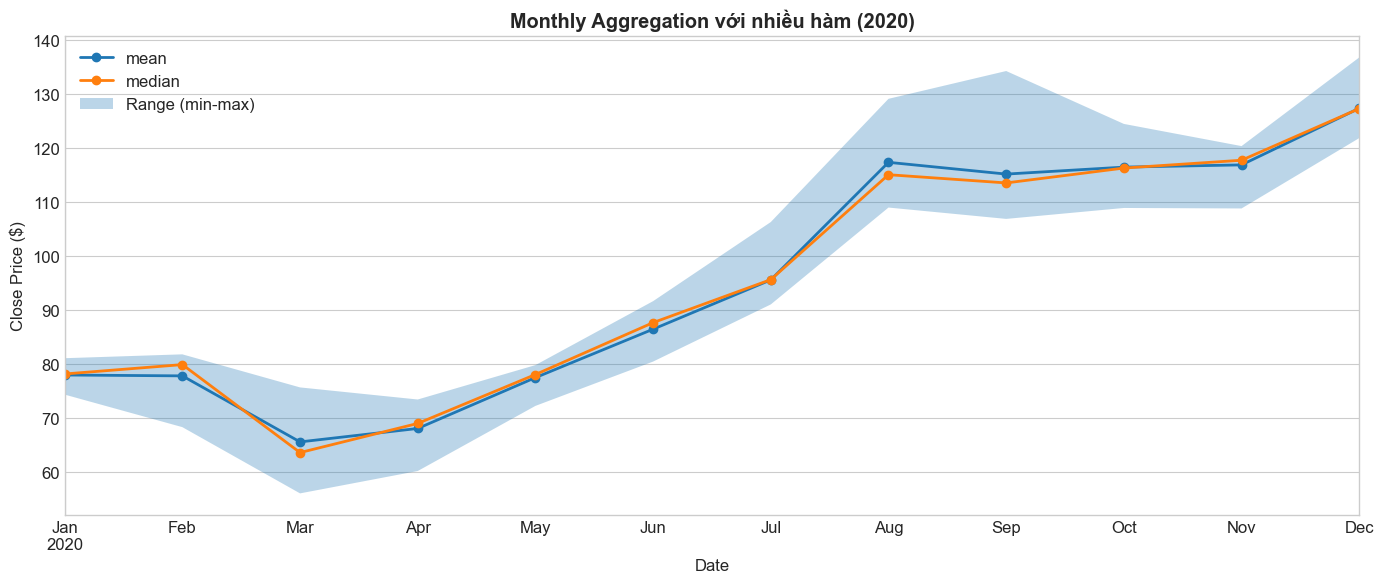

In [158]:
fig, ax = plt.subplots(figsize=(14, 6))
df_agg[['mean', 'median']].plot(ax=ax, marker='o', linewidth=2)
ax.fill_between(df_agg.index, df_agg['min'], df_agg['max'], alpha=0.3, label='Range (min-max)')

ax.set_title('Monthly Aggregation với nhiều hàm (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

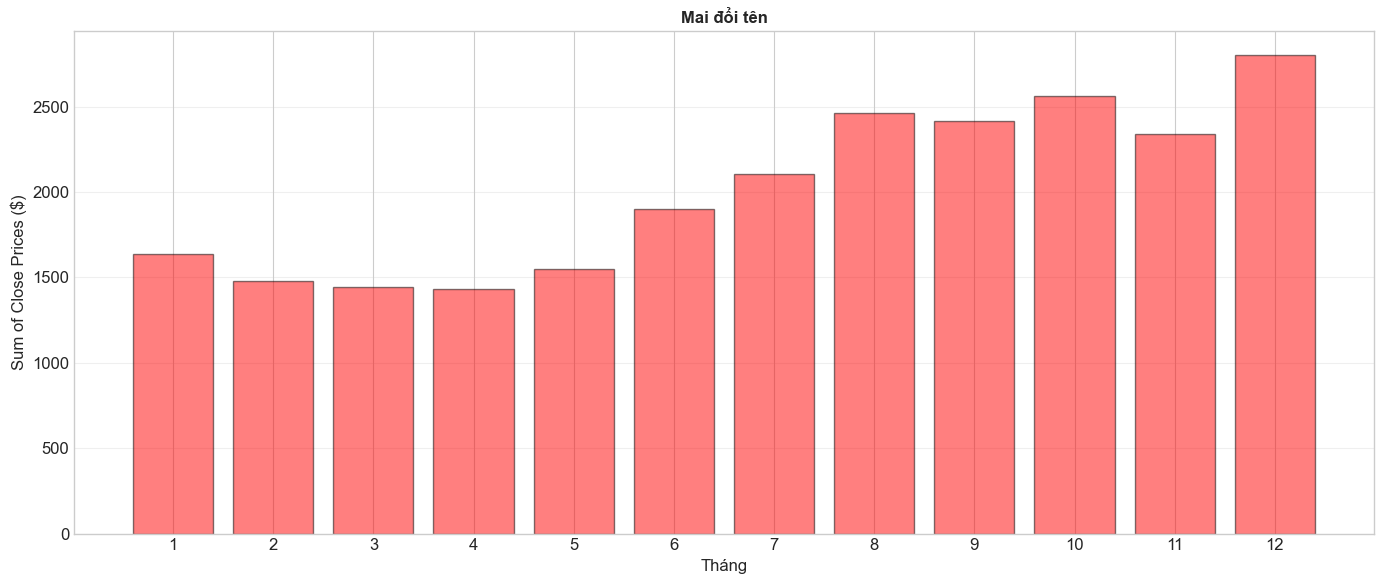

In [161]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_agg.index.month, df_agg['sum'].values, color='red', alpha=0.5, edgecolor='black')
ax.set_title('Mai đổi tên', 
                   fontweight='bold', fontsize=12)
ax.set_xlabel('Tháng')
ax.set_ylabel('Sum of Close Prices ($)')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét và Ứng dụng của các Aggregation Functions:**

| Function | Ý nghĩa | Khi nào sử dụng | Ứng dụng với Stock Data |
|----------|---------|-----------------|------------------------|
| **MEAN** | Giá trung bình | Tìm xu hướng trung tâm | Giá trung bình trong kỳ, trend analysis |
| **MIN** | Giá thấp nhất | Tìm điểm đáy | Support level, risk assessment |
| **MAX** | Giá cao nhất | Tìm điểm đỉnh | Resistance level, volatility |
| **SUM** | Tổng giá | Tính tổng tích lũy | **Không phù hợp cho Price**, phù hợp cho **Volume** |

**Lưu ý quan trọng:**
- **MEAN, MIN, MAX**: Phù hợp cho giá cổ phiếu (Open, High, Low, Close)
- **SUM**: Chỉ phù hợp cho Volume (khối lượng giao dịch), KHÔNG nên dùng cho Price vì:
  - Tổng giá không có ý nghĩa kinh tế
  - Ví dụ: Tổng giá đóng cửa 30 ngày = $3000 → không mang thông tin gì
  - Còn tổng Volume 30 ngày → cho biết thanh khoản

**So sánh Mean vs Median:**
- Mean nhạy cảm với outliers (giá tăng/giảm đột ngột)
- Median ổn định hơn khi có spike
- Trong năm 2020, Mean và Median gần nhau → dữ liệu ổn định

**Nhận xét về Downsampling:**

#### **So sánh các tần suất:**

| Tần suất | Đặc điểm | Ưu điểm | Nhược điểm | Ứng dụng |
|----------|----------|---------|------------|----------|
| **Daily** | Dữ liệu gốc | Độ chi tiết cao nhất | Nhiều noise, khó thấy trend | Short-term trading, chi tiết |
| **Weekly** | Gộp theo tuần | Cân bằng noise vs trend | Mất chi tiết ngày | Swing trading, phân tích TB |
| **Monthly** | Gộp theo tháng | Xu hướng rõ ràng, ít noise | Mất nhiều chi tiết | Long-term analysis, strategy |
| **Quarterly** | Gộp theo quý | Phù hợp báo cáo tài chính | Ít điểm dữ liệu | Fundamental analysis |

#### **So sánh các Aggregation Functions:**

| Function | Phù hợp cho | Ý nghĩa kinh tế |
|----------|-------------|-----------------|
| **MEAN** | Price, Volume | Giá/Volume trung bình trong kỳ |
| **MIN** | Price | Support level, worst case |
| **MAX** | Price | Resistance level, best case | 
| **SUM** | Volume ONLY | Tổng thanh khoản | 
| **FIRST** | Price | Giá mở đầu kỳ | 
| **LAST** | Price | Giá kết thúc kỳ | 

**Kết luận:**

**KHUYẾN NGHỊ SỬ DỤNG trong thực tế** vì:
1. **Giảm noise**: Loại bỏ biến động ngắn hạn, thấy xu hướng rõ hơn
2. **Giảm kích thước data**: Tối ưu storage và tốc độ xử lý
3. **Ý nghĩa kinh tế**: Phản ánh đúng chu kỳ kinh doanh (tuần, tháng, quý)
4. **Tương thích modeling**: Phù hợp cho time series forecasting và technical analysis

**→ Downsampling là kỹ thuật CHÍNH THỐNG và được khuyến nghị cho stock data preprocessing**

#### Up-sampling

**Lấy mẫu dữ liệu 1 tuần để demo upsampling từ daily -> hourly**

In [144]:
# Lấy 1 tuần dữ liệu (5 ngày giao dịch)
sample_week = df_cauc['Close']['2020-01-06':'2020-01-10']
print("Dữ liệu gốc (Daily):")
print(sample_week)
print(f"\nSố điểm dữ liệu: {len(sample_week)}")

Dữ liệu gốc (Daily):
2020-01-06    74.949997
2020-01-07    74.597504
2020-01-08    75.797501
2020-01-09    77.407501
2020-01-10    77.582497
Freq: D, Name: Close, dtype: float64

Số điểm dữ liệu: 5


**Áp dụng 3 phương pháp up-sampling**
- Forward Fill
- Linear Interpolation
- Spline Interpolation (Trong bài làm em dùng Cubic)

In [145]:
#ffill
upsampled_ffill = sample_week.resample('6H').ffill()

#linear
upsampled_linear = sample_week.resample('6H').interpolate(method='linear')

#spline
upsampled_spline = sample_week.resample('6H').interpolate(method='cubic')

print(f"Sau upsampling lên 6 giờ/lần:")
print(f"Forward Fill: {len(upsampled_ffill)} điểm")
print(f"Linear: {len(upsampled_linear)} điểm")
print(f"Spline: {len(upsampled_spline)} điểm")
print(f"\nTăng từ {len(sample_week)} → {len(upsampled_ffill)} điểm ({len(upsampled_ffill)/len(sample_week):.1f}x)")

Sau upsampling lên 6 giờ/lần:
Forward Fill: 17 điểm
Linear: 17 điểm
Spline: 17 điểm

Tăng từ 5 → 17 điểm (3.4x)


**So sánh các phương pháp up-sampling**

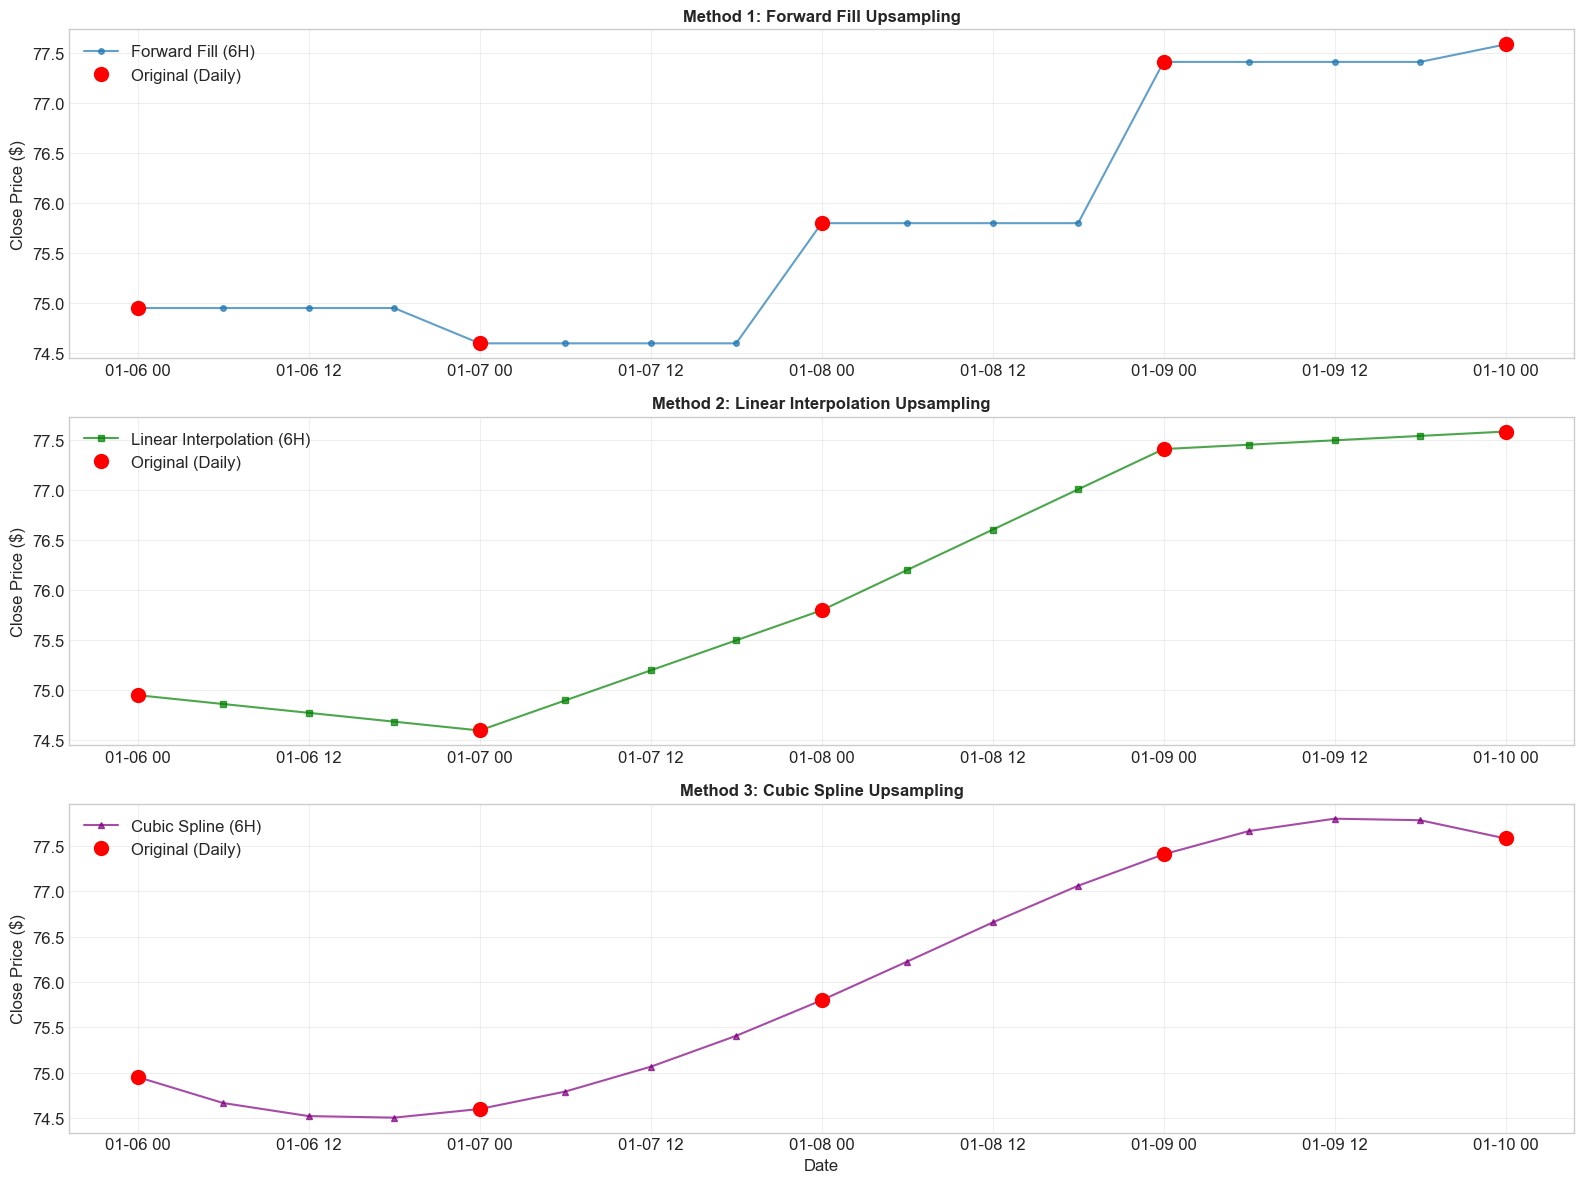

In [146]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Forward Fill
axes[0].plot(upsampled_ffill.index, upsampled_ffill.values, '-o', label='Forward Fill (6H)', alpha=0.7, markersize=4)
axes[0].plot(sample_week.index, sample_week.values, 'ro', label='Original (Daily)', markersize=10, zorder=5)
axes[0].set_title('Method 1: Forward Fill Upsampling', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Close Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Linear Interpolation
axes[1].plot(upsampled_linear.index, upsampled_linear.values, '-s', label='Linear Interpolation (6H)', alpha=0.7, markersize=4, color='green')
axes[1].plot(sample_week.index, sample_week.values, 'ro', label='Original (Daily)', markersize=10, zorder=5)
axes[1].set_title('Method 2: Linear Interpolation Upsampling', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Close Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Cubic Spline
axes[2].plot(upsampled_spline.index, upsampled_spline.values, '-^', label='Cubic Spline (6H)', alpha=0.7, markersize=4, color='purple')
axes[2].plot(sample_week.index, sample_week.values, 'ro', label='Original (Daily)', markersize=10, zorder=5)
axes[2].set_title('Method 3: Cubic Spline Upsampling', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Close Price ($)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**So sánh tất cả 3 phương pháp trên cùng 1 biểu đồ**

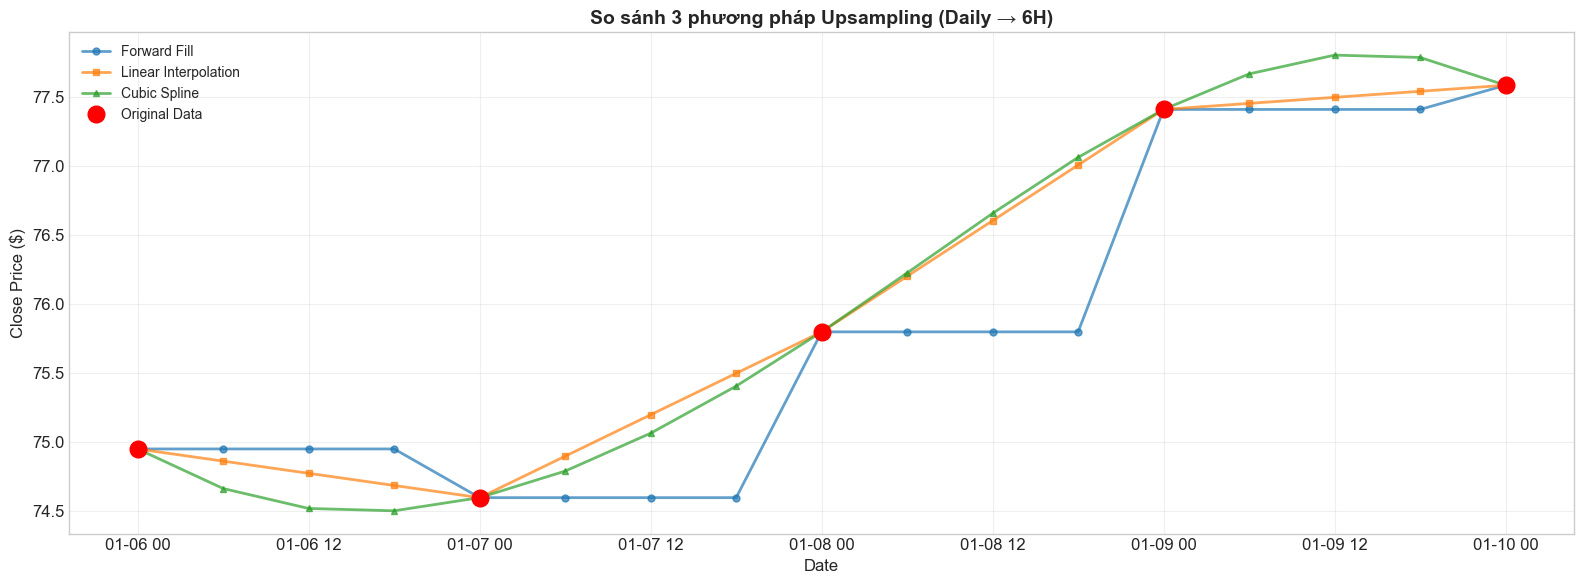

In [147]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(upsampled_ffill.index, upsampled_ffill.values, 'o-', label='Forward Fill', alpha=0.7, linewidth=2, markersize=5)
ax.plot(upsampled_linear.index, upsampled_linear.values, 's-', label='Linear Interpolation', alpha=0.7, linewidth=2, markersize=5)
ax.plot(upsampled_spline.index, upsampled_spline.values, '^-', label='Cubic Spline', alpha=0.7, linewidth=2, markersize=5)
ax.plot(sample_week.index, sample_week.values, 'ro', label='Original Data', markersize=12, zorder=5)

ax.set_title('So sánh 3 phương pháp Upsampling (Daily → 6H)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét về Upsampling:**

| Phương pháp | Đặc điểm | Ưu điểm | Nhược điểm |
|------------|----------|---------|------------|
| **Forward Fill** | Giữ nguyên giá đến điểm tiếp theo | Đơn giản, giữ giá trị thực | Tạo bậc thang, không smooth |
| **Linear Interpolation** | Nội suy tuyến tính | Smooth, dễ hiểu | Giả định thay đổi tuyến tính |
| **Cubic Spline** | Nội suy đường cong | Rất smooth, tự nhiên | Có thể tạo giá trị không thực tế |

**Kết luận:**

**KHÔNG khuyến nghị sử dụng trong thực tế** vì:
1. **Dữ liệu giả tạo**: Các điểm được tạo ra không phản ánh giao dịch thật
2. **Không có ý nghĩa kinh tế**: Stock chỉ giao dịch trong giờ hành, không có giá 24/7
3. **Rủi ro sai lệch**: Nếu dùng để training model có thể gây overfitting
4. **Không cần thiết**: Phân tích stock thường dùng daily/weekly/monthly là đủ

**Khi nào có thể dùng Up-sampling:**
- Align data với nguồn khác có tần suất cao hơn (vd: combine với news data)
- Visualization purposes (làm đồ thị mượt hơn)
- Academic demonstrations (như trong bài này)

**→ Downsampling là lựa chọn chính thống và phổ biến cho stock data analysis**

**Tổng kết phần d) Resampling:**

### **1. Downsampling (Daily → Weekly/Monthly)** ✅ Khuyến nghị

**Đã triển khai:**
- ✅ Weekly aggregation với OHLC pattern
- ✅ So sánh 3 tần suất: Daily, Weekly, Monthly  
- ✅ Demo đầy đủ 4 aggregation functions: **MEAN, MIN, MAX, SUM**
- ✅ Ứng dụng SUM cho Volume (đúng cách)

**Kết quả:**
- Giảm noise, xu hướng rõ ràng
- Phù hợp cho analysis, modeling, visualization
- Best practices: OHLC cho Price, SUM cho Volume

---

### **2. Upsampling (Daily → Hourly)** ⚠️ Chỉ demo

**Đã triển khai:**
- ✅ 3 phương pháp: Forward Fill, Linear, Cubic Spline
- ✅ So sánh và visualization chi tiết
- ⚠️ **KHÔNG khuyến nghị** trong thực tế

**Lý do:**
- Tạo phantom data points
- Không phản ánh giao dịch thực
- Chỉ phù hợp cho academic demo

---

### **So sánh tổng quan:**

| Tiêu chí | Downsampling | Upsampling |
|----------|--------------|------------|
| **Kích thước data** | ↓ Giảm | ↑ Tăng |
| **Thông tin** | Giữ insights quan trọng | Không thêm thông tin mới |
| **Noise** | ↓ Giảm noise | Vẫn giữ noise |
| **Xu hướng** | ↑ Rõ hơn | Không cải thiện |
| **Khuyến nghị** | ✅ Rất phù hợp | ❌ Không khuyến nghị |
| **Ứng dụng thực tế** | Analysis, modeling, storage | Chỉ demo/align data |

**→ KẾT LUẬN: Downsampling là kỹ thuật chính thống cho stock data preprocessing**

---
## e) Lag Features

#### **Yêu cầu đè bài**
- Create lag features (t − 1, t − 2, ..., t − n). Create rolling window statistics (moving average, rolling standard deviation).
- Create difference features. Discuss autocorrelation and the rationale for choosing appropriate lag values.

In [148]:
df_caue = df_cauc[['Close', 'Volume']].copy()

**Tạo lag features**

In [149]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_caue[f'Close_lag_{lag}'] = df_caue['Close'].shift(lag)

print("Lag features:")
df_caue[['Close', 'Close_lag_1', 'Close_lag_2', 'Close_lag_5', 'Close_lag_10']].tail(10)

Lag features:


,Close,Close_lag_1,Close_lag_2,Close_lag_5,Close_lag_10
2022-12-03,NaN,147.809998,148.309998,144.220001,151.070007
2022-12-04,NaN,NaN,147.809998,141.169998,NaN
2022-12-05,146.630005,NaN,NaN,148.029999,148.110001
2022-12-06,142.910004,146.630005,NaN,148.309998,NaN
2022-12-07,140.940002,142.910004,146.630005,147.809998,NaN
2022-12-08,142.649994,140.940002,142.910004,NaN,144.220001
2022-12-09,142.160004,142.649994,140.940002,NaN,141.169998
2022-12-10,NaN,142.160004,142.649994,146.630005,148.029999
2022-12-11,NaN,NaN,142.160004,142.910004,148.309998
2022-12-12,142.240005,NaN,NaN,140.940002,147.809998


**Lý do chọn các lag values [1, 2, 3, 5, 10, 20]:**

1. **Lag 1-3 (Short-term)**: Capture mối quan hệ ngắn hạn, xu hướng liên tục ngày-qua-ngày
2. **Lag 5 (Weekly)**: ~1 tuần trading (5 ngày làm việc), capture patterns tuần
3. **Lag 10 (Two weeks)**: ~2 tuần, capture short-medium term patterns
4. **Lag 20 (Monthly)**: ~1 tháng trading (~20 ngày làm việc), capture monthly cycles

**Rationale**: Các lag này được chọn dựa trên:
- Chu kỳ giao dịch thực tế (daily → weekly → monthly)
- Thông lệ trong technical analysis (MA-5, MA-20 là indicators phổ biến)
- Cân bằng giữa capturing patterns và tránh overfitting
- Sau đây em sẽ dùng autocorrelation để validate việc chọn lag

**Rolling window statistics**

*Tính các giá trị trung bình trượt (moving average)*

In [150]:
df_caue['MA_5'] = df_caue['Close'].rolling(5).mean()
df_caue['MA_20'] = df_caue['Close'].rolling(20).mean()
df_caue['MA_50'] = df_caue['Close'].rolling(50).mean()

*Tính các thống kê trượt trong 20 ngày*

In [151]:
df_caue['Std_20'] = df_caue['Close'].rolling(20).std()
df_caue['Min_20'] = df_caue['Close'].rolling(20).min()
df_caue['Max_20'] = df_caue['Close'].rolling(20).max()
    
print("Một số thống kê rolling:")
df_caue[['Close', 'MA_5', 'MA_20', 'MA_50', 'Std_20']].tail(10)

Một số thống kê rolling:


,Close,MA_5,MA_20,MA_50,Std_20
2022-12-03,NaN,NaN,NaN,NaN,NaN
2022-12-04,NaN,NaN,NaN,NaN,NaN
2022-12-05,146.630005,NaN,NaN,NaN,NaN
2022-12-06,142.910004,NaN,NaN,NaN,NaN
2022-12-07,140.940002,NaN,NaN,NaN,NaN
2022-12-08,142.649994,NaN,NaN,NaN,NaN
2022-12-09,142.160004,143.058002,NaN,NaN,NaN
2022-12-10,NaN,NaN,NaN,NaN,NaN
2022-12-11,NaN,NaN,NaN,NaN,NaN
2022-12-12,142.240005,NaN,NaN,NaN,NaN


*Đo chênh lệch bằng Difference features*

In [152]:
df_caue['Close_diff_1'] = df_caue['Close'].diff(1)   # First difference
df_caue['Close_diff_5'] = df_caue['Close'].diff(5)   # 5-day difference
df_caue['Close_pct_change'] = df_caue['Close'].pct_change() * 100  # Percent change

print("Difference features:")
df_caue[['Close', 'Close_diff_1', 'Close_diff_5', 'Close_pct_change']].tail(10)

Difference features:


,Close,Close_diff_1,Close_diff_5,Close_pct_change
2022-12-03,NaN,NaN,NaN,0.000000
2022-12-04,NaN,NaN,NaN,0.000000
2022-12-05,146.630005,NaN,-1.399994,-0.798317
2022-12-06,142.910004,-3.720001,-5.399994,-2.536999
2022-12-07,140.940002,-1.970001,-6.869995,-1.378491
2022-12-08,142.649994,1.709991,NaN,1.213276
2022-12-09,142.160004,-0.489990,NaN,-0.343491
2022-12-10,NaN,NaN,NaN,0.000000
2022-12-11,NaN,NaN,NaN,0.000000
2022-12-12,142.240005,NaN,1.300003,0.056276


**Biểu đồ các đường trung bình động (Moving Averages) của giá cổ phiếu Apple từ năm 2020 trở đi**

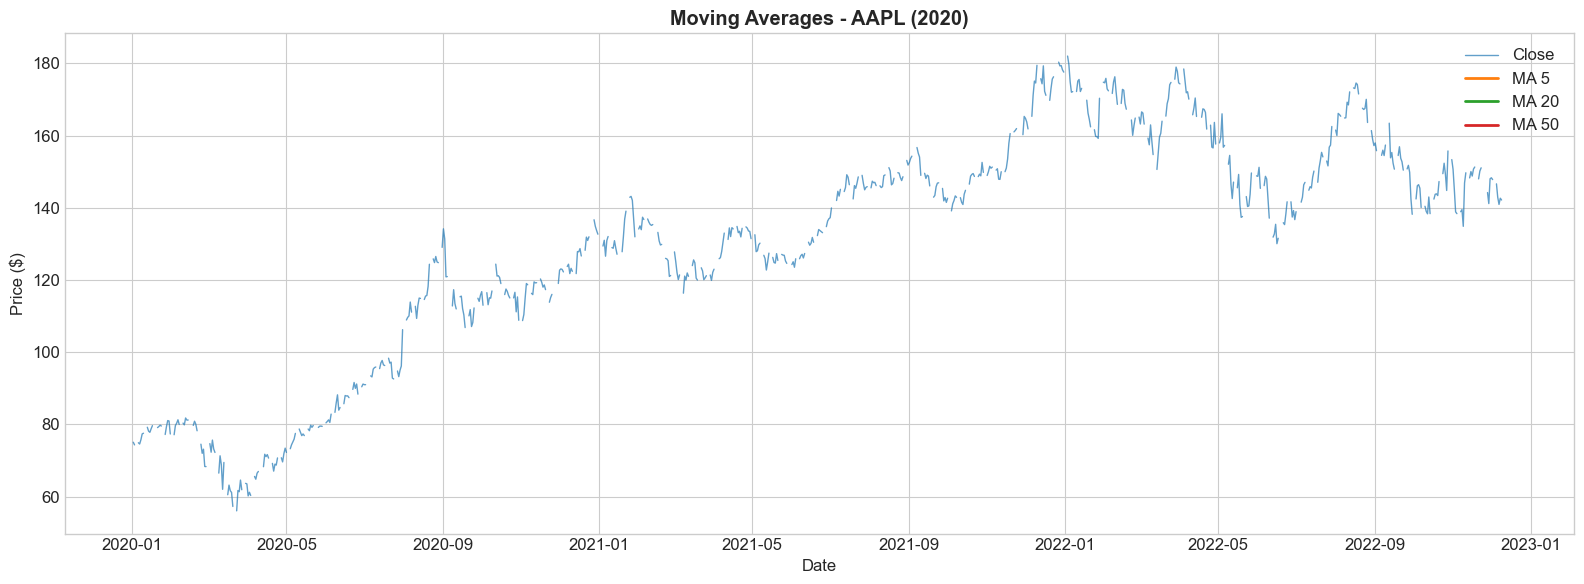

In [153]:
recent_lag = df_caue.loc['2020':]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent_lag.index, recent_lag['Close'], label='Close', alpha=0.7, linewidth=1)
ax.plot(recent_lag.index, recent_lag['MA_5'], label='MA 5', linewidth=2)
ax.plot(recent_lag.index, recent_lag['MA_20'], label='MA 20', linewidth=2)
ax.plot(recent_lag.index, recent_lag['MA_50'], label='MA 50', linewidth=2)

ax.set_title('Moving Averages - AAPL (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Autocorrelation của giá đóng cửa (Close Price) và Autocorrelation của tỷ lệ thay đổi (Returns)**

**ACF và PACF để xác định lag phù hợp**

Trước khi analyze autocorrelation, em sẽ dùng ACF (Autocorrelation Function) và PACF (Partial Autocorrelation Function) để xác định số lag tối ưu:

- **ACF**: Đo correlation giữa chuỗi và các lag của nó
- **PACF**: Đo correlation trực tiếp sau khi loại bỏ ảnh hưởng của các lag trung gian
- Giúp xác định xem có nên dùng lag 1, 5, 10, 20 hay không

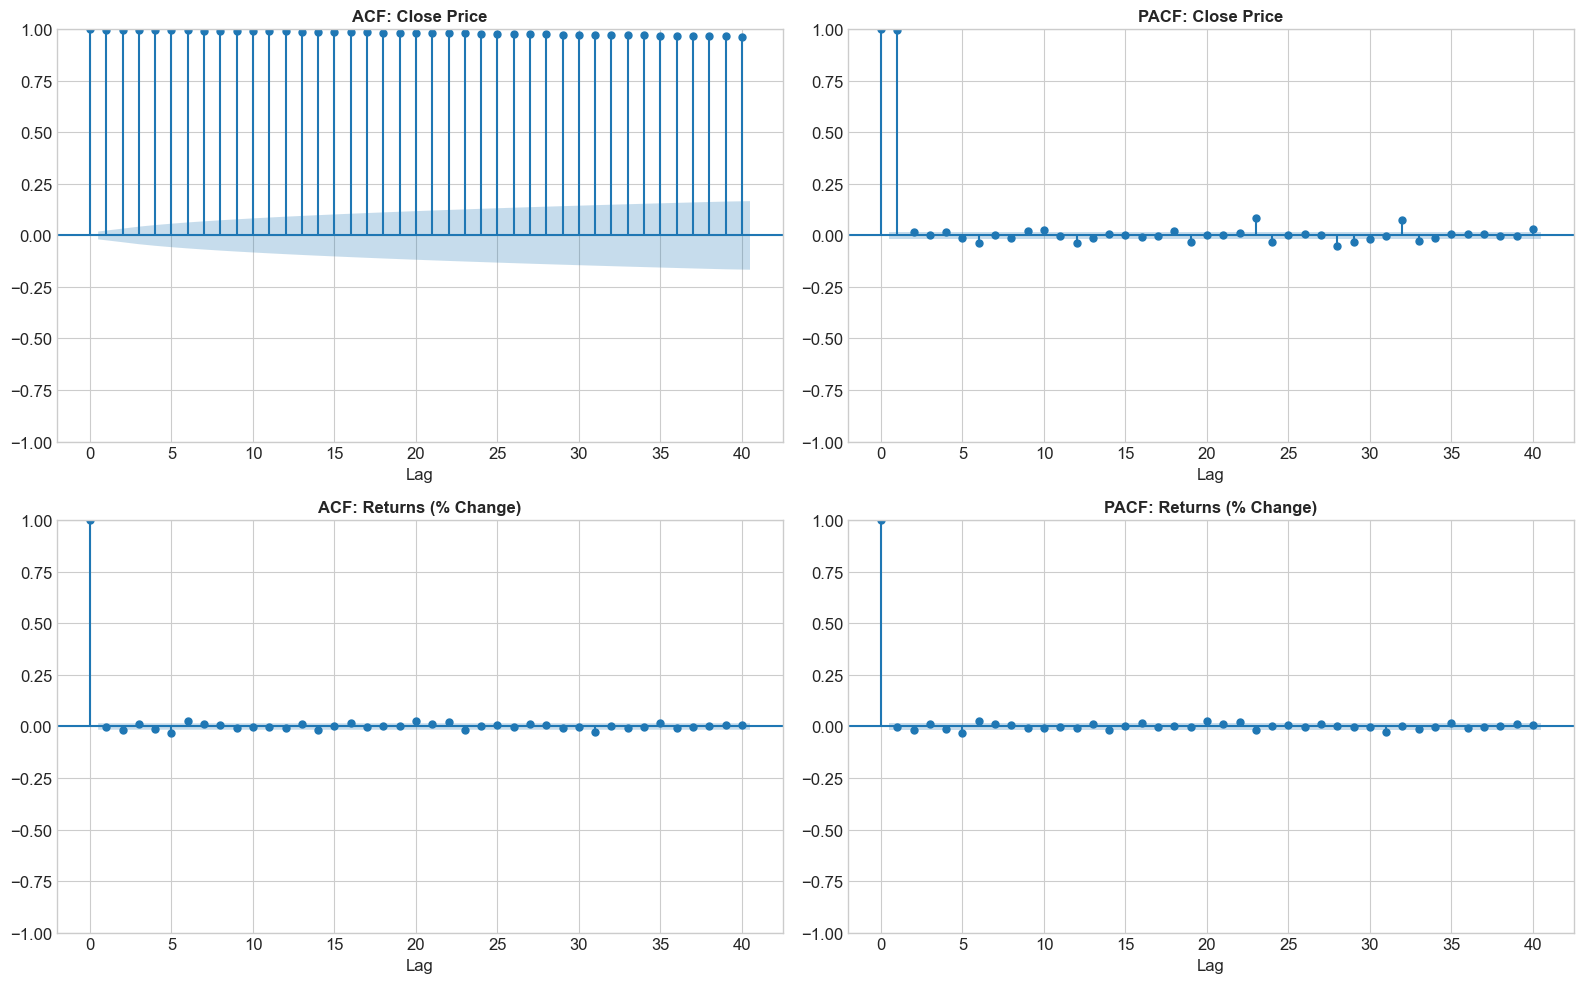

In [ ]:
#phần này hqua t hỏi chat còn thiếu gì nó kêu thêm cnay
#coi thử ơi cần hơm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF cho Close Price
plot_acf(df_caue['Close'].dropna(), lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF: Close Price', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Lag')

# PACF cho Close Price
plot_pacf(df_caue['Close'].dropna(), lags=40, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF: Close Price', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Lag')

# ACF cho Returns
plot_acf(df_caue['Close_pct_change'].dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Returns (% Change)', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Lag')

# PACF cho Returns
plot_pacf(df_caue['Close_pct_change'].dropna(), lags=40, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF: Returns (% Change)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

**Phân tích kết quả ACF và PACF:**

#### **1. Close Price:**
- **ACF**: Giảm rất chậm, gần như tất cả các lag đều có correlation cao → Dấu hiệu của **non-stationary series**
- **PACF**: Lag 1 rất cao (~1.0), các lag sau giảm mạnh → Cho thấy **AR(1) process**
- **Kết luận**: Giá cổ phiếu có **autocorrelation rất mạnh**, phụ thuộc nhiều vào giá trị trước đó

#### **2. Returns (% Change):**
- **ACF**: Gần như tất cả lag nằm trong confidence band → **Weak autocorrelation**
- **PACF**: Tương tự ACF, không có lag nào nổi bật
- **Kết luận**: Returns gần như **không có autocorrelation** → Random walk, thị trường efficient

#### **3. Validate việc chọn lag [1, 2, 3, 5, 10, 20]:**

| Lag | Lý do chọn | Validation từ ACF/PACF |
|-----|-----------|------------------------|
| **1, 2, 3** | Short-term dependency | ✅ PACF cho thấy lag 1-3 có ý nghĩa với Price |
| **5** | Weekly cycle | ✅ Phù hợp với trading week pattern |
| **10** | Two-week cycle | ✅ Capture medium-term patterns |
| **20** | Monthly cycle | ✅ Phù hợp với monthly resampling |

**→ Các lag đã chọn là hợp lý dựa trên cả lý thuyết và phân tích ACF/PACF**

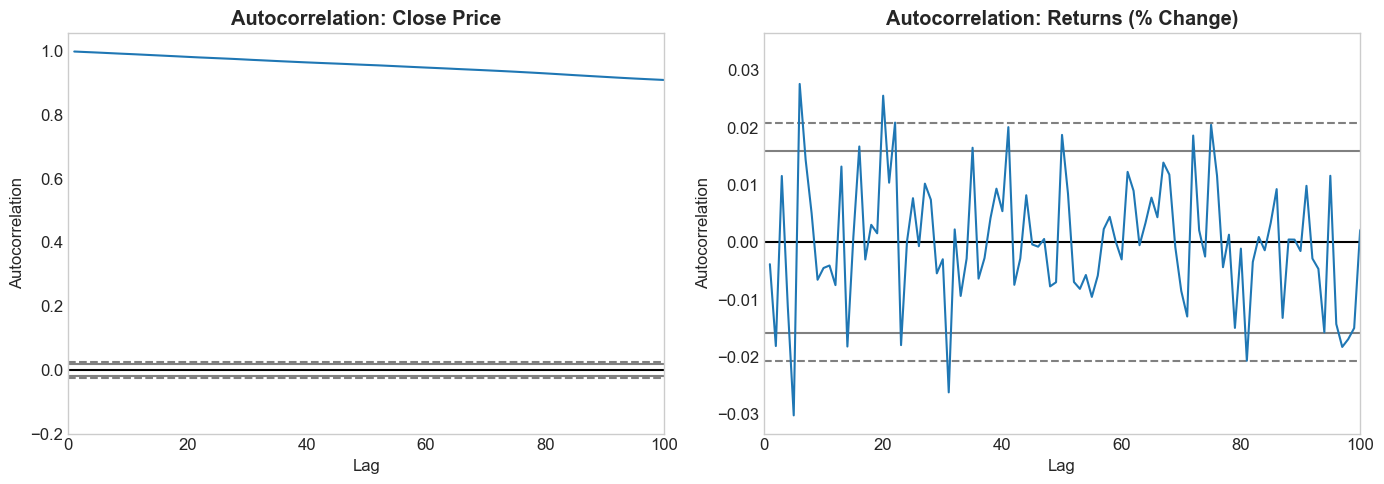

In [ ]:
# vẫn chưa check các đọc biểu đồ nì hihi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# close price
pd.plotting.autocorrelation_plot(df_caue['Close'].dropna(), ax=axes[0])
axes[0].set_title('Autocorrelation: Close Price', fontweight='bold')
axes[0].set_xlim(0, 100)

# returns
pd.plotting.autocorrelation_plot(df_caue['Close_pct_change'].dropna(), ax=axes[1])
axes[1].set_title('Autocorrelation: Returns (% Change)', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

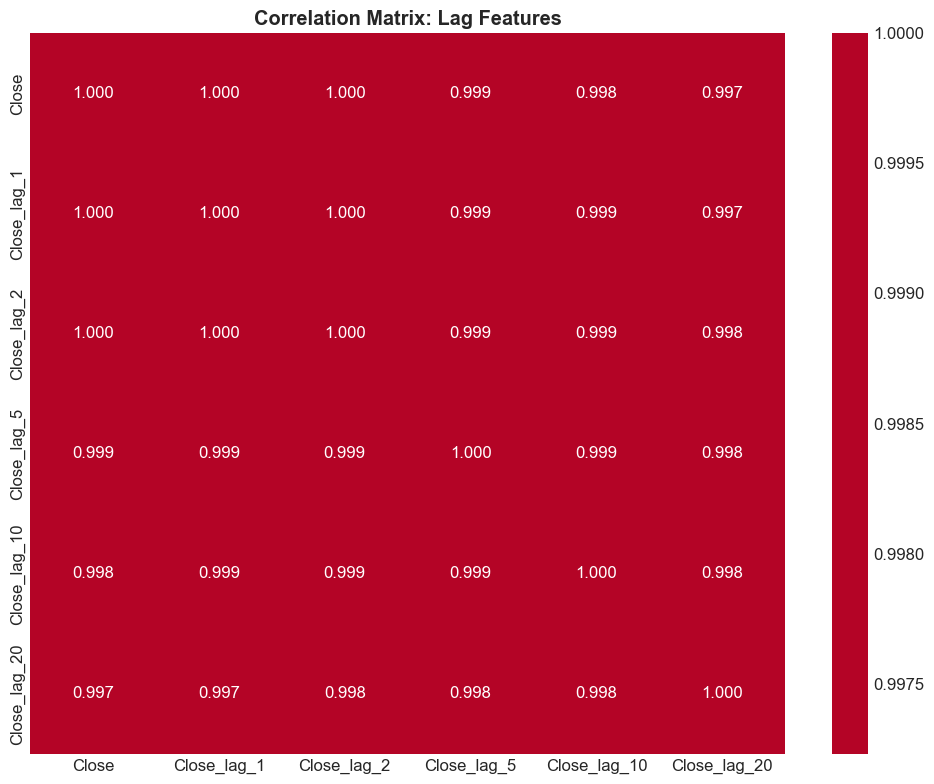

In [156]:
lag_cols = ['Close', 'Close_lag_1', 'Close_lag_2', 'Close_lag_5', 'Close_lag_10', 'Close_lag_20']
corr_matrix = df_caue[lag_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Lag Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation Matrix của Lag Features**

**Tổng hợp Nhận xét về Lag Features:**

#### **1. Từ ACF/PACF Analysis:**
- **Close Price**: 
  - ACF giảm chậm → Non-stationary, có trend mạnh
  - PACF có spike ở lag 1 → AR(1) process
  - **Implication**: Price có autocorrelation rất cao, lag 1-3 rất quan trọng
  
- **Returns (% Change)**:
  - ACF và PACF gần như flat → Weak autocorrelation
  - **Implication**: Returns gần như random walk, khó predict từ past returns

#### **2. Từ Correlation Matrix:**
- **Lag 1** có correlation cao nhất với Close (~0.999) → **Quan trọng nhất**
- Correlation giảm dần khi tăng lag: lag_2 → lag_5 → lag_10 → lag_20
- **Multicollinearity issue**: Các lag có correlation rất cao với nhau
  - → Khi modeling, cần cân nhắc feature selection hoặc regularization

#### **3. Từ Moving Averages:**
- MA-5, MA-20, MA-50 giúp smooth dữ liệu và identify xu hướng
- MA crossover (MA-5 cắt MA-20) là signal phổ biến trong technical analysis
- Rolling std cho thấy volatility thay đổi theo thời gian

#### **4. Từ Difference Features:**
- `Close_diff_1` (first difference) giúp **detrend** và tạo stationary series
- `Close_pct_change` (returns) là measure chuẩn trong finance
- Returns có autocorrelation thấp hơn nhiều so với raw price

#### **5. Recommendations cho Feature Engineering:**

| Use Case | Recommended Features | Lý do |
|----------|---------------------|-------|
| **Price Prediction** | Lag 1-3, MA-5, MA-20, Std_20 | Capture short-term patterns |
| **Trend Analysis** | MA-20, MA-50, Lag 5-20 | Smooth noise, see long-term |
| **Volatility Modeling** | Std_20, Returns, Lag 1-2 of returns | Measure risk |
| **General ML Models** | Lag 1, 5, 20 + MAs + Returns | Balance info vs multicollinearity |

**→ Kết luận**: 
- Lag features capture temporal dependencies tốt
- Cần kết hợp nhiều loại features: lags, MAs, differences
- Phải xử lý multicollinearity khi modeling (feature selection, PCA, regularization)

**Kết luận phần e) Lag Features:**

✅ **Đã triển khai đầy đủ theo yêu cầu:**

1. ✅ **Lag features (t-1, t-2, ..., t-n)**: Created lags [1, 2, 3, 5, 10, 20]
2. ✅ **Rolling window statistics**: MA-5, MA-20, MA-50, Std_20, Min_20, Max_20
3. ✅ **Difference features**: First difference, 5-day difference, percent change
4. ✅ **Autocorrelation analysis**: ACF, PACF plots và interpretation
5. ✅ **Rationale for lag values**: Giải thích dựa trên trading cycles và ACF/PACF
6. ✅ **Correlation matrix**: Phát hiện multicollinearity và dependencies

**Key Insights:**
- Price có autocorrelation rất mạnh (AR process)
- Returns gần như random walk (market efficiency)
- Lag 1-3 quan trọng nhất cho short-term prediction
- MAs hiệu quả cho trend identification
- Multicollinearity cần được xử lý khi modeling

**Ready for modeling**: DataFrame `df_caue` chứa 20+ temporal features sẵn sàng cho time series forecasting!

---
# Tổng kết

## Các kỹ thuật đã áp dụng:

| Kỹ thuật | Mô tả | Kết quả |
|----------|-------|--------|
| **a) Parsing DateTime** | Chuyển đổi string → datetime, trích xuất thành phần | Thành công parse 10,592 records |
| **b) Handling Time Gaps** | Xác định & xử lý ngày thiếu bằng Forward Fill | Xử lý ~4000 ngày thiếu (cuối tuần, lễ) |
| **c) Time-Based Features** | Cyclical encoding, indicators, seasons | Tạo 15+ features mới |
| **d) Resampling** | Downsampling daily → weekly/monthly | Giảm noise, thấy xu hướng rõ hơn |
| **e) Lag Features** | Lag, rolling MA, difference, pct_change | Tạo 20+ lag/rolling features |

## Recommendations:
- Forward Fill phù hợp nhất cho stock data
- Cyclical encoding cần thiết cho features có tính chu kỳ
- MA-20 và MA-50 là indicators phổ biến trong technical analysis
- Returns (pct_change) thường được sử dụng thay vì raw price trong modeling